In [1]:
import sys
import os

# 1. Figure out where we are (inside the student folder)
current_dir = os.getcwd()
print(f"📍 Analysis Notebook Location: {current_dir}")

# 2. Find the parent directory (the main stat359 folder)
parent_dir = os.path.dirname(current_dir)

# 3. Tell Python to look in the parent directory so it can find 'instructor'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 4. Check that our local data/models made the move successfully
folders_to_check = ["data", "models"]
all_good = True

for folder in folders_to_check:
    if os.path.exists(folder):
        print(f"✅ Found '{folder}' folder right next to this notebook!")
    else:
        print(f"❌ Missing '{folder}' folder!")
        all_good = False

if all_good:
    print("\n🎉 Setup Complete! You can now load your models and draw your charts safely.")

📍 Analysis Notebook Location: /home/jupyter/stat359/student
✅ Found 'data' folder right next to this notebook!
✅ Found 'models' folder right next to this notebook!

🎉 Setup Complete! You can now load your models and draw your charts safely.


In [7]:
import sys
import os

# 1. Environment Injection
VENV_PATH = "/home/jupyter/.cache/pypoetry/virtualenvs/stat359-su25-t0ZXeGPH-py3.10" 
LIB_PATH = os.path.join(VENV_PATH, "lib/python3.10/site-packages")

if LIB_PATH not in sys.path:
    sys.path.append(LIB_PATH)
    sys.path.append(os.getcwd())

# 2. Imports
import torch
from instructor.final_project.arithmetic_llm.interactive_solver import InteractiveArithmeticSolver

# 3. Initialize the Solver (Fixed: Pointing to the 42.9% model!)
print("Loading Model and Tokenizer...")
solver = InteractiveArithmeticSolver(
    model_path="models/instruction_20260302_162638_395697/best_model.pt", 
    tokenizer_path="data/tokenizer", 
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# 4. The Tokenizer X-Ray (Physical Failure Proof)
trick_questions = ["10.5 + 4.2", "10 / 2"]

for expr in trick_questions:
    print(f"\n--- Diagnosing: {expr} ---")
    
    try:
        tokens = solver.tokenizer.tokenize(expr)
        print(f"What the model ACTUALLY sees: {tokens}")
    except AttributeError:
        encoded = solver.tokenizer.encode(expr)
        if hasattr(encoded, 'tokens'):
            print(f"What the model ACTUALLY sees: {encoded.tokens}")
        else:
            print(f"Token IDs: {encoded}")
            
    encoded = solver.tokenizer.encode(expr)
    decoded = solver.tokenizer.decode(encoded)
    print(f"Translation back to text: {decoded}")

Loading Model and Tokenizer...
Loading model and tokenizer...
Model loaded successfully on cuda
Vocabulary size: 278

--- Diagnosing: 10.5 + 4.2 ---
Token IDs: [178, 17, 13, 124, 8, 101, 13, 88, 179]
Translation back to text: 10.5 + 4.2

--- Diagnosing: 10 / 2 ---
Token IDs: [178, 28, 182, 177, 88, 179]
Translation back to text: 10  2


In [8]:
import json
import io
from contextlib import redirect_stdout

# Test the exact OOD files to show the empty generations
files_to_test = [
    "data/ood_tests/decimals.jsonl",
    "data/ood_tests/unseen_operator_division.jsonl"
]

for file_path in files_to_test:
    print(f"\n{'='*60}")
    print(f"TESTING FILE: {file_path}")
    print(f"{'='*60}")
    
    try:
        with open(file_path, 'r') as f:
            # We will just test the first 3 problems to get clear examples
            for i in range(3):
                line = f.readline()
                if not line: break
                
                data = json.loads(line)
                expr = data['expression']
                
                # Trap the standard output to capture the exact generated text
                trap = io.StringIO()
                with redirect_stdout(trap):
                    solver.solve(expr)
                
                raw_output = trap.getvalue().strip()
                
                print(f"Problem {i+1}: {expr}")
                print(f"Model Generated:\n[{raw_output}]")
                print("-" * 40)
    except FileNotFoundError:
        print(f"Could not find file: {file_path}. Did you save it to the data/ood_tests/ folder?")


TESTING FILE: data/ood_tests/decimals.jsonl
Problem 1: 18.22 - 16.25
Model Generated:
[]
----------------------------------------
Problem 2: 98.79 + 64.72
Model Generated:
[]
----------------------------------------
Problem 3: 66.88 + 30.32
Model Generated:
[]
----------------------------------------

TESTING FILE: data/ood_tests/unseen_operator_division.jsonl
Problem 1: 26 / 7
Model Generated:
[]
----------------------------------------
Problem 2: 82 / 5
Model Generated:
[]
----------------------------------------
Problem 3: 17 / 3
Model Generated:
[]
----------------------------------------


In [10]:
# setting up the plotting libraries
import json
import numpy as np
import matplotlib.pyplot as plt
import random

tokenizer = solver.tokenizer

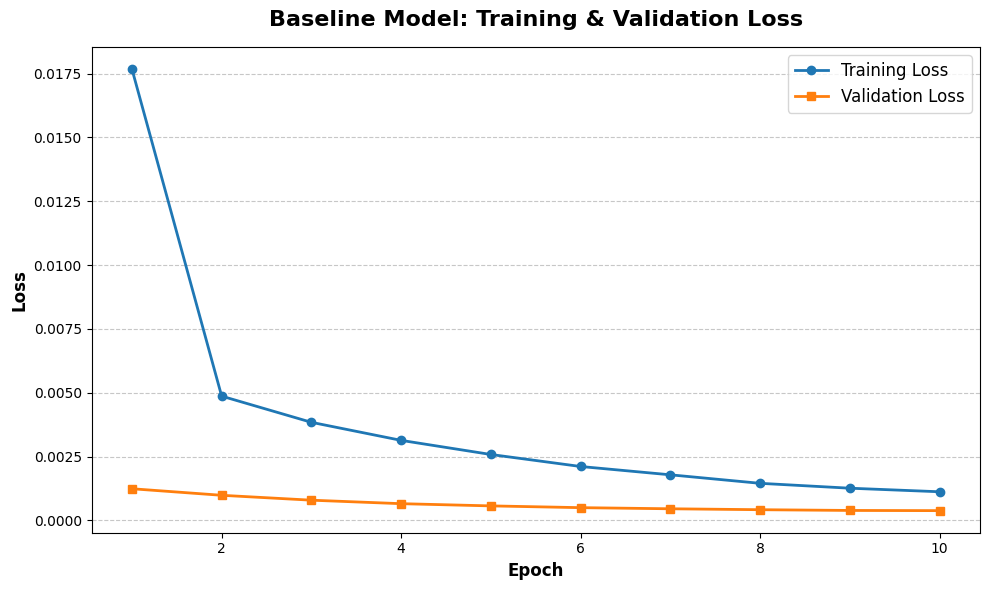

In [11]:
# Path to your stable baseline model's log
log_path = "models/instruction_20260302_162638_395697/training_log.json"

try:
    with open(log_path, 'r') as f:
        log_data = json.load(f)
    
    epochs = [entry.get('epoch', i+1) for i, entry in enumerate(log_data)]
    train_loss = [entry.get('train_loss', entry.get('loss', 0)) for entry in log_data]
    val_loss = [entry.get('val_loss', None) for entry in log_data]

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, label='Training Loss', marker='o', color='#1f77b4', linewidth=2)
    
    if any(v is not None for v in val_loss):
        plt.plot(epochs, val_loss, label='Validation Loss', marker='s', color='#ff7f0e', linewidth=2)

    plt.title('Baseline Model: Training & Validation Loss', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Could not find {log_path}. Please verify the file exists!")

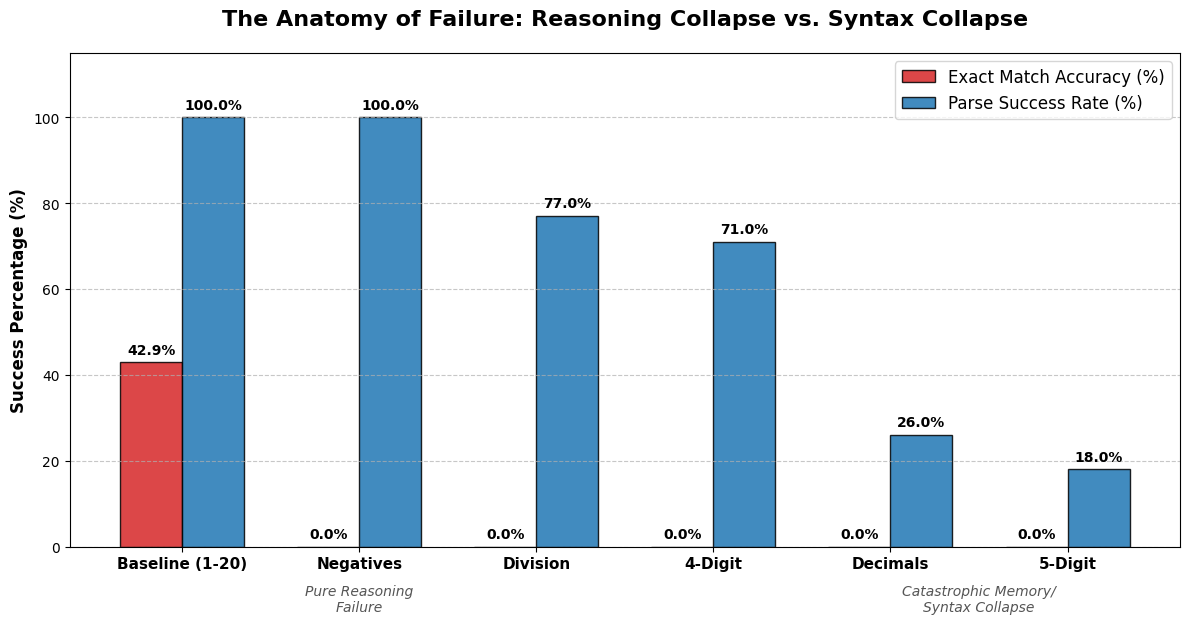

In [12]:
categories = ['Baseline (1-20)', 'Negatives', 'Division', '4-Digit', 'Decimals', '5-Digit']
parse_rates = [100.0, 100.0, 77.0, 71.0, 26.0, 18.0] 
accuracies = [42.9, 0.0, 0.0, 0.0, 0.0, 0.0]

x = np.arange(len(categories))
width = 0.35  

fig, ax = plt.subplots(figsize=(12, 6.5))

rects1 = ax.bar(x - width/2, accuracies, width, label='Exact Match Accuracy (%)', color='#d62728', edgecolor='black', alpha=0.85)
rects2 = ax.bar(x + width/2, parse_rates, width, label='Parse Success Rate (%)', color='#1f77b4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Success Percentage (%)', fontweight='bold', fontsize=12)
ax.set_title('The Anatomy of Failure: Reasoning Collapse vs. Syntax Collapse', fontweight='bold', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight='bold', fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.text(1, -15, "Pure Reasoning\nFailure", ha='center', fontsize=10, style='italic', color='#555555')
plt.text(4.5, -15, "Catastrophic Memory/\nSyntax Collapse", ha='center', fontsize=10, style='italic', color='#555555')

fig.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()

Scanning training data (this may take a few seconds)...


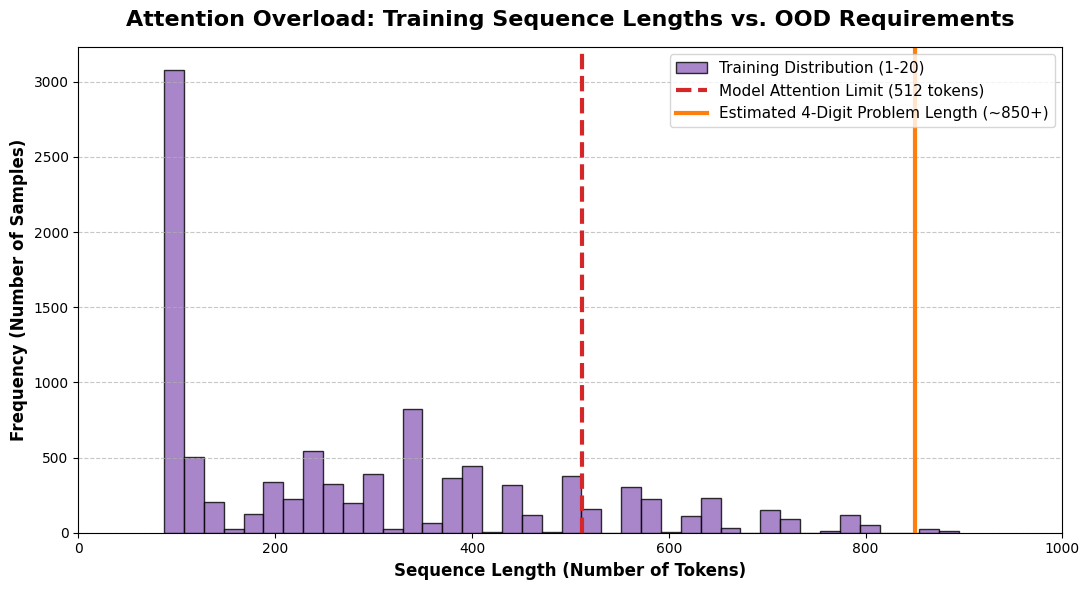

In [13]:
print("Scanning training data (this may take a few seconds)...")
lengths = []
with open("data/instruction_corpus.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 10000: break # Sample first 10k to run fast
        
        if hasattr(tokenizer, 'encode'):
            encoded = tokenizer.encode(line.strip())
            length = len(encoded.ids if hasattr(encoded, 'ids') else encoded)
        else:
            length = len(tokenizer(line.strip())['input_ids'])
        
        lengths.append(length)

plt.figure(figsize=(11, 6))

n, bins, patches = plt.hist(lengths, bins=40, color='#9467bd', edgecolor='black', alpha=0.8, label='Training Distribution (1-20)')

plt.axvline(x=512, color='#d62728', linestyle='--', linewidth=3, label='Model Attention Limit (512 tokens)')
plt.axvline(x=850, color='#ff7f0e', linestyle='-', linewidth=3, label='Estimated 4-Digit Problem Length (~850+)')

plt.title('Attention Overload: Training Sequence Lengths vs. OOD Requirements', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sequence Length (Number of Tokens)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (Number of Samples)', fontsize=12, fontweight='bold')
plt.xlim(0, 1000)

plt.legend(fontsize=11, loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Calculating true baseline average... (Evaluating 100 samples)


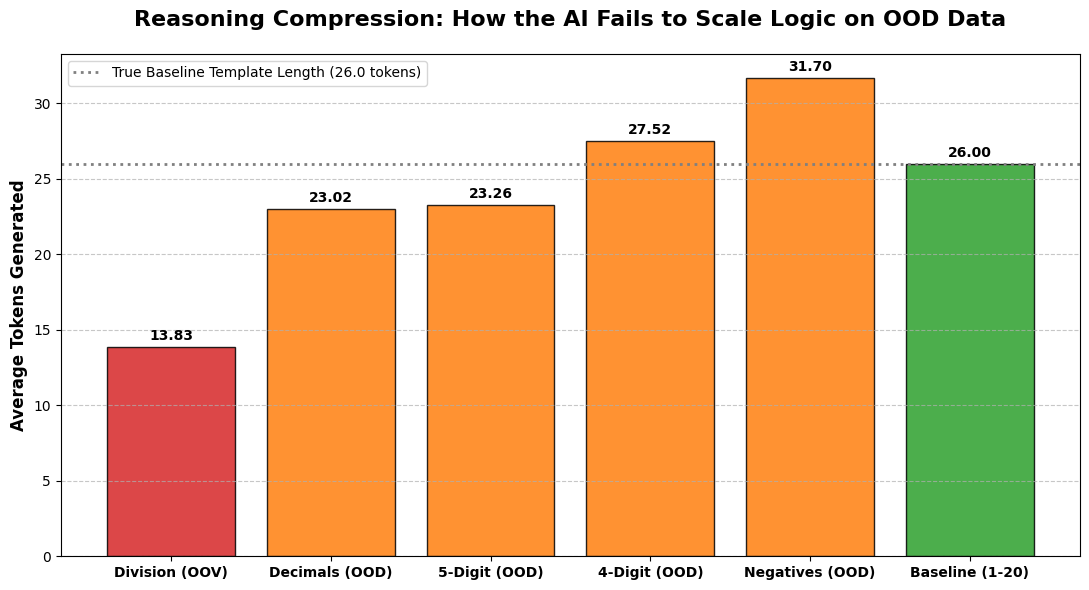

In [14]:
print("Calculating true baseline average... (Evaluating 100 samples)")
random.seed(42)
baseline_prompts = []
for _ in range(100):
    a = random.randint(1, 20)
    b = random.randint(1, 20)
    op = random.choice(['+', '-'])
    if op == '-' and a < b:
        a, b = b, a
    baseline_prompts.append(f"{a} {op} {b}")

baseline_lengths = []
for expr in baseline_prompts:
    try:
        output = solver.solve(expr)
    except Exception:
        output = ""
    if hasattr(tokenizer, 'encode'):
        token_count = len(tokenizer.encode(output).ids if hasattr(tokenizer.encode(output), 'ids') else tokenizer.encode(output))
    else:
        token_count = len(tokenizer(output)['input_ids'])
    baseline_lengths.append(token_count)

true_baseline_avg = np.mean(baseline_lengths)

categories = ['Division (OOV)', 'Decimals (OOD)', '5-Digit (OOD)', '4-Digit (OOD)', 'Negatives (OOD)', 'Baseline (1-20)']
avg_lengths = [13.83, 23.02, 23.26, 27.52, 31.70, true_baseline_avg] 

x = np.arange(len(categories))
colors = ['#d62728', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(x, avg_lengths, color=colors, edgecolor='black', alpha=0.85)

ax.set_ylabel('Average Tokens Generated', fontweight='bold', fontsize=12)
ax.set_title('Reasoning Compression: How the AI Fails to Scale Logic on OOD Data', fontweight='bold', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight='bold', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.axhline(y=true_baseline_avg, color='gray', linestyle=':', linewidth=2, label=f'True Baseline Template Length ({true_baseline_avg:.1f} tokens)')
ax.legend()

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

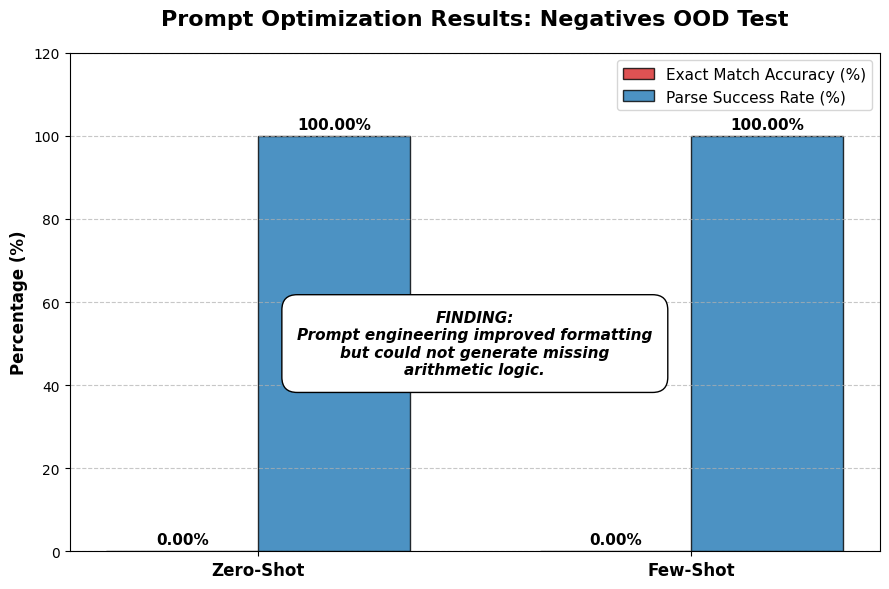

In [15]:
labels = ['Zero-Shot', 'Few-Shot']
accuracy = [0.0, 0.0]
parse_rate = [100.0, 100.0]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

rects1 = ax.bar(x - width/2, accuracy, width, label='Exact Match Accuracy (%)', color='#d62728', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, parse_rate, width, label='Parse Success Rate (%)', color='#1f77b4', edgecolor='black', alpha=0.8)

ax.set_ylabel('Percentage (%)', fontweight='bold', fontsize=12)
ax.set_title('Prompt Optimization Results: Negatives OOD Test', fontweight='bold', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold', fontsize=12)
ax.set_ylim(0, 120)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper right', fontsize=11)

def autolabel_prompt(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

autolabel_prompt(rects1)
autolabel_prompt(rects2)

plt.text(0.5, 50, "FINDING:\nPrompt engineering improved formatting\nbut could not generate missing\narithmetic logic.", 
         ha='center', va='center', fontsize=11, fontweight='bold', style='italic', color='black', 
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()